# Notebook 01 — Preprocesamiento y Epoching

**Proyecto:** Clasificación de ensayos EEG (match vs mismatch) — Track A · ML Clásico
**Autores:** Jose Pablo Agüero Mora, Roilin Navarro Vargas

## ¿Qué hace este notebook?

Es el primer paso del procesamiento real de datos. Toma los archivos `.set` crudos (uno por sujeto, 29 sujetos) y los convierte en **epochs limpias listas para extraer features** (lo que hará el Notebook 02).

Para cada sujeto, hacemos en orden:

1. **Cargar** el archivo `.set` como objeto `Epochs` de MNE.
2. **Aplicar baseline correction** restando la amplitud promedio de la ventana pre-estímulo (−100 a 0 ms). Esto centra cada epoch alrededor de cero antes del evento.
3. **Seleccionar solo los eventos `Correct`** (`matchTarget/Correct` y `mismatchTarget/Correct`).
4. **Rechazar epochs con artefactos** usando peak-to-peak > umbral en µV.
5. **Guardar** las epochs limpias como `.fif` en `features/epochs_clean/`.

Al final generamos un CSV maestro, una figura grand-average ERP, y un reporte por sujeto.

## Resiliencia a desconexiones

El notebook detecta sujetos ya procesados (sus `.fif` existen) y los salta. Si Colab se desconecta a mitad de procesamiento, retomas donde se cortó.

## 1. Setup

Ajustar `PROJECT_ROOT_DRIVE` si el repo está en otra ruta.

In [3]:
PROJECT_ROOT_DRIVE = '/content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400'
FORCE_RERUN = False  # poner True si quieres reprocesar aunque los .fif ya existan

print(f'PROJECT_ROOT_DRIVE: {PROJECT_ROOT_DRIVE}')
print(f'FORCE_RERUN:        {FORCE_RERUN}')

PROJECT_ROOT_DRIVE: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400
FORCE_RERUN:        False


## 2. Instalación de dependencias

Usamos versiones modernas compatibles con NumPy 2.x (lo que Colab tiene por defecto). El `%%capture` silencia los warnings de pip.

**Importante:** después de esta celda viene una que mata el kernel para forzar reinicio limpio. Tras el reinicio, Colab carga las librerías frescas. Luego corres TODAS las celdas desde el principio nuevamente.

In [4]:
%%capture
!pip install -q --upgrade --no-cache-dir "shap>=0.46.0"
!pip install -q mne==1.12.1
!pip install -q scikit-learn xgboost lightgbm optuna
!pip install -q pyxdf openpyxl pyyaml tqdm jedi

### Reinicio forzado del kernel

La celda de abajo **mata el proceso del kernel** para que Python recargue todo limpio (sin esto, las librerías viejas siguen en memoria). Colab reinicia automáticamente. Tras el reinicio:

1. La celda de instalación NO necesita correrse de nuevo (los paquetes quedan instalados).
2. Empezar a ejecutar desde la celda 1 (PROJECT_ROOT_DRIVE).
3. Saltarse esta celda de `os.kill` la segunda vez.

In [ ]:
# Solo ejecutar esta celda la PRIMERA vez (después de instalar). En el segundo pase, saltarla.
import os
os.kill(os.getpid(), 9)

## 3. Imports y verificación de versiones

In [1]:
import os
import sys
import json
import yaml
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import mne
mne.set_log_level('WARNING')

import sklearn, xgboost, lightgbm, optuna, shap
print('TODO IMPORTÓ BIEN')
print(f'Python:       {sys.version.split()[0]}')
print(f'NumPy:        {np.__version__}')
print(f'Pandas:       {pd.__version__}')
print(f'MNE-Python:   {mne.__version__}')
print(f'scikit-learn: {sklearn.__version__}')
print(f'XGBoost:      {xgboost.__version__}')
print(f'LightGBM:     {lightgbm.__version__}')
print(f'Optuna:       {optuna.__version__}')
print(f'SHAP:         {shap.__version__}')

TODO IMPORTÓ BIEN
Python:       3.12.13
NumPy:        2.0.2
Pandas:       2.2.2
MNE-Python:   1.12.1
scikit-learn: 1.6.1
XGBoost:      3.2.0
LightGBM:     4.6.0
Optuna:       4.8.0
SHAP:         0.51.0


## 4. Montaje de Drive y carga de configuración

In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

assert os.path.exists(PROJECT_ROOT_DRIVE), f'No existe: {PROJECT_ROOT_DRIVE}'

# Cargar config
CONFIG_PATH = Path(PROJECT_ROOT_DRIVE) / 'configs' / 'main_config.yaml'
with open(CONFIG_PATH, 'r') as f:
    CFG = yaml.safe_load(f)

# Semillas
SEED = CFG['seed']
random.seed(SEED)
np.random.seed(SEED)

# Rutas
DATASET_ROOT = Path(CFG['paths']['dataset_root'])
REPORTS_DIR  = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['reports_dir']
FIGURES_DIR  = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['figures_dir']
EPOCHS_DIR   = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['epochs_dir']
EPOCHS_DIR.mkdir(parents=True, exist_ok=True)

P_INCLUDED = DATASET_ROOT / 'EEG Data' / 'Processed EEG' / 'Included'

print(f'✓ Config cargada: {CONFIG_PATH}')
print(f'✓ EPOCHS_DIR:     {EPOCHS_DIR}')
print(f'✓ Sujetos en Included: {len(list(P_INCLUDED.glob("*allepochs.set")))}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Config cargada: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/configs/main_config.yaml
✓ EPOCHS_DIR:     /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/features/epochs_clean
✓ Sujetos en Included: 29


## 5. Verificar que el Notebook 00 corrió

In [6]:
inventory_path = REPORTS_DIR / '00_dataset_inventory.json'
assert inventory_path.exists(), 'No existe el inventario del Notebook 00. Ejecuta primero 00_setup_and_verify.ipynb'

with open(inventory_path, 'r') as f:
    inventory = json.load(f)

assert inventory['scenario'] == 'A_epochs', f'Escenario inesperado: {inventory["scenario"]}'

INCLUDED_FILES = inventory['included_files']
print(f'✓ Notebook 00 corrió correctamente.')
print(f'  Escenario: {inventory["scenario"]}')
print(f'  Sujetos a procesar: {len(INCLUDED_FILES)}')

✓ Notebook 00 corrió correctamente.
  Escenario: A_epochs
  Sujetos a procesar: 29


## 6. Función de procesamiento por sujeto

In [7]:
def process_subject(set_path, subject_id, cfg):
    """
    Procesa un sujeto: carga, baseline, filtra a Correct, rechaza artefactos.
    """
    stats = {'subject': subject_id}

    # 1. Cargar
    try:
        epochs = mne.io.read_epochs_eeglab(str(set_path), verbose='ERROR')
    except Exception as e:
        stats['error'] = f'load: {str(e)[:120]}'
        return None, stats

    stats['n_loaded']    = len(epochs)
    stats['ch_names']    = epochs.ch_names
    stats['n_channels']  = len(epochs.ch_names)
    stats['sfreq']       = float(epochs.info['sfreq'])
    stats['tmin_ms']     = float(epochs.tmin * 1000)
    stats['tmax_ms']     = float(epochs.tmax * 1000)

    # 1b. Verificar canales esperados
    expected_channels = cfg['data']['channels']
    missing = [ch for ch in expected_channels if ch not in epochs.ch_names]
    if missing:
        stats['error'] = f'canales faltantes: {missing}'
        return None, stats
    epochs = epochs.pick_channels(expected_channels, ordered=True)

    # 2. Baseline correction
    if cfg['preprocessing']['apply_baseline']:
        bl = (cfg['preprocessing']['baseline_tmin'],
              cfg['preprocessing']['baseline_tmax'])
        epochs = epochs.apply_baseline(bl, verbose='ERROR')
        stats['baseline_applied'] = list(bl)

    # 3. Filtrar a solo Correct
    match_key    = cfg['labels']['match_event']
    mismatch_key = cfg['labels']['mismatch_event']
    available_events = list(epochs.event_id.keys())

    keys_to_select = [k for k in [match_key, mismatch_key] if k in available_events]
    if len(keys_to_select) < 2:
        stats['error'] = f'eventos faltantes. Disponibles: {available_events}'
        return None, stats

    epochs = epochs[keys_to_select]
    stats['n_after_correct_filter'] = len(epochs)

    id_to_name = {v: k for k, v in epochs.event_id.items()}
    cnt = Counter(id_to_name[c] for c in epochs.events[:, 2])
    stats['n_match_correct_before_reject']    = cnt.get(match_key, 0)
    stats['n_mismatch_correct_before_reject'] = cnt.get(mismatch_key, 0)

    # 4. Rechazo por peak-to-peak
    reject_uv = cfg['preprocessing']['artifact_rejection_uv']
    reject_dict = {'eeg': reject_uv * 1e-6}  # MNE espera en Volts
    epochs.drop_bad(reject=reject_dict, verbose='ERROR')
    stats['n_after_artifact_reject'] = len(epochs)
    stats['rejection_threshold_uv']  = reject_uv

    if len(epochs) > 0:
        id_to_name = {v: k for k, v in epochs.event_id.items()}
        cnt = Counter(id_to_name[c] for c in epochs.events[:, 2])
        stats['n_match_correct_final']    = cnt.get(match_key, 0)
        stats['n_mismatch_correct_final'] = cnt.get(mismatch_key, 0)
    else:
        stats['n_match_correct_final']    = 0
        stats['n_mismatch_correct_final'] = 0

    return epochs, stats

print('✓ Función `process_subject` definida.')

✓ Función `process_subject` definida.


## 7. Procesamiento de los 29 sujetos

In [8]:
all_stats = []
subjects_processed = 0
subjects_skipped   = 0
subjects_failed    = []

for fname in tqdm(INCLUDED_FILES, desc='Procesando sujetos'):
    subject_id = fname.split(' ')[0]
    set_path = P_INCLUDED / fname
    fif_path = EPOCHS_DIR / f'{subject_id}-epo.fif'
    stats_path = EPOCHS_DIR / f'{subject_id}-stats.json'

    if fif_path.exists() and stats_path.exists() and not FORCE_RERUN:
        with open(stats_path, 'r') as f:
            stats = json.load(f)
        all_stats.append(stats)
        subjects_skipped += 1
        continue

    epochs_clean, stats = process_subject(set_path, subject_id, CFG)

    if epochs_clean is None or len(epochs_clean) == 0:
        subjects_failed.append((subject_id, stats.get('error', 'sin epochs')))
        all_stats.append(stats)
        continue

    epochs_clean.save(str(fif_path), overwrite=True, verbose='ERROR')
    with open(stats_path, 'w') as f:
        json.dump(stats, f, indent=2, default=str)

    all_stats.append(stats)
    subjects_processed += 1

print(f'\n=== RESUMEN ===')
print(f'Procesados ahora:      {subjects_processed}')
print(f'Saltados (ya hechos):  {subjects_skipped}')
print(f'Fallidos:              {len(subjects_failed)}')
if subjects_failed:
    print('\nDetalle de fallos:')
    for s, e in subjects_failed:
        print(f'  ✗ {s}: {e}')

Procesando sujetos:   0%|          | 0/29 [00:00<?, ?it/s]


=== RESUMEN ===
Procesados ahora:      29
Saltados (ya hechos):  0
Fallidos:              0


## 8. Tabla resumen de procesamiento

In [9]:
df_stats = pd.DataFrame(all_stats)

display_cols = [
    'subject', 'n_loaded',
    'n_match_correct_before_reject', 'n_mismatch_correct_before_reject',
    'n_match_correct_final', 'n_mismatch_correct_final',
    'n_after_artifact_reject',
]
display_cols = [c for c in display_cols if c in df_stats.columns]

df_show = df_stats[display_cols].fillna(0)
for c in df_show.columns:
    if c != 'subject':
        df_show[c] = df_show[c].astype(int)

print('=== EPOCHS POR SUJETO (antes y después de rechazo) ===\n')
print(df_show.to_string(index=False))

print('\n=== TOTALES ===')
print(f'matchTarget/Correct antes:    {df_show["n_match_correct_before_reject"].sum():>5}')
print(f'matchTarget/Correct final:    {df_show["n_match_correct_final"].sum():>5}')
print(f'mismatchTarget/Correct antes: {df_show["n_mismatch_correct_before_reject"].sum():>5}')
print(f'mismatchTarget/Correct final: {df_show["n_mismatch_correct_final"].sum():>5}')

n_total = df_show['n_match_correct_final'].sum() + df_show['n_mismatch_correct_final'].sum()
n_match = df_show['n_match_correct_final'].sum()
n_mism  = df_show['n_mismatch_correct_final'].sum()
print(f'\nTotal epochs limpias:         {n_total}')
print(f'Porcentaje match:             {100*n_match/n_total:.1f}%')
print(f'Porcentaje mismatch:          {100*n_mism/n_total:.1f}%')
tasa = 100 * (1 - df_show[['n_match_correct_final','n_mismatch_correct_final']].sum().sum() /
              df_show[['n_match_correct_before_reject','n_mismatch_correct_before_reject']].sum().sum())
print(f'Tasa de rechazo de artefactos: {tasa:.1f}%')

summary_path = REPORTS_DIR / '01_preprocessing_summary.csv'
df_show.to_csv(summary_path, index=False)
print(f'\n✓ Guardado: {summary_path}')

=== EPOCHS POR SUJETO (antes y después de rechazo) ===

subject  n_loaded  n_match_correct_before_reject  n_mismatch_correct_before_reject  n_match_correct_final  n_mismatch_correct_final  n_after_artifact_reject
mu02erp        95                             33                                13                     33                        13                       46
mu04erp        63                             22                                 7                     22                         7                       29
mu05erp        91                             40                                21                     40                        21                       61
mu07erp        92                             21                                 3                     21                         3                       24
mu08erp       107                             28                                20                     28                        20                       48
mu

## 9. CSV maestro de epochs limpias

In [10]:
master_rows = []
label_map = {
    CFG['labels']['match_event']:    CFG['labels']['class_map'][CFG['labels']['match_event']],
    CFG['labels']['mismatch_event']: CFG['labels']['class_map'][CFG['labels']['mismatch_event']],
}

for fname in tqdm(INCLUDED_FILES, desc='Construyendo CSV maestro'):
    subject_id = fname.split(' ')[0]
    fif_path = EPOCHS_DIR / f'{subject_id}-epo.fif'
    if not fif_path.exists():
        continue
    epochs = mne.read_epochs(str(fif_path), verbose='ERROR')
    id_to_name = {v: k for k, v in epochs.event_id.items()}
    for i, code in enumerate(epochs.events[:, 2]):
        cond = id_to_name[code]
        master_rows.append({
            'subject_id': subject_id,
            'epoch_idx':  i,
            'condition':  cond,
            'label':      label_map.get(cond, -1),
        })

df_master = pd.DataFrame(master_rows)
print(f'\nTotal de epochs en CSV maestro: {len(df_master)}')
print(f'\nDistribución por clase:')
print(df_master['label'].value_counts().sort_index().rename({0:'match (0)', 1:'mismatch (1)'}).to_string())
print(f'\nSujetos representados: {df_master["subject_id"].nunique()}')

master_path = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['features_dir'] / '01_epochs_master.csv'
df_master.to_csv(master_path, index=False)
print(f'\n✓ Guardado: {master_path}')

Construyendo CSV maestro:   0%|          | 0/29 [00:00<?, ?it/s]


Total de epochs en CSV maestro: 1520

Distribución por clase:
label
-1               17
match (0)       865
mismatch (1)    638

Sujetos representados: 29

✓ Guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/features/01_epochs_master.csv


## 10. ⭐ Grand-average ERP

Promediamos las epochs de TODOS los sujetos por condición. Si el efecto N400 está en el dataset, debería verse claramente aquí — mucho más claro que en un solo sujeto.

Buscamos: en **AF8**, la curva roja (mismatch) debería ser **más negativa** que la azul (match) entre 250 y 600 ms aproximadamente.

In [11]:
all_match    = []
all_mismatch = []

for fname in tqdm(INCLUDED_FILES, desc='Cargando epochs para grand-average'):
    subject_id = fname.split(' ')[0]
    fif_path = EPOCHS_DIR / f'{subject_id}-epo.fif'
    if not fif_path.exists():
        continue
    epochs = mne.read_epochs(str(fif_path), verbose='ERROR')
    if CFG['labels']['match_event'] in epochs.event_id:
        all_match.append(epochs[CFG['labels']['match_event']].average())
    if CFG['labels']['mismatch_event'] in epochs.event_id:
        all_mismatch.append(epochs[CFG['labels']['mismatch_event']].average())

print(f'Sujetos con match average:    {len(all_match)}')
print(f'Sujetos con mismatch average: {len(all_mismatch)}')

ga_match    = mne.grand_average(all_match)
ga_mismatch = mne.grand_average(all_mismatch)

Cargando epochs para grand-average:   0%|          | 0/29 [00:00<?, ?it/s]

Sujetos con match average:    29
Sujetos con mismatch average: 29



✓ Figura guardada: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/01_grand_average_ERP.png


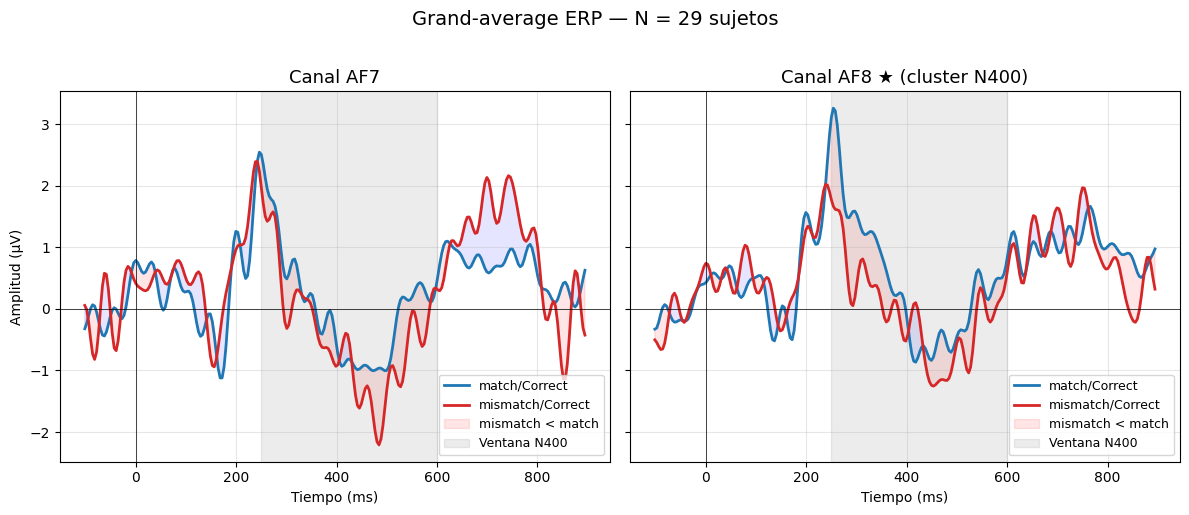

In [12]:
n400_t1 = CFG['n400']['window_tmin'] * 1000
n400_t2 = CFG['n400']['window_tmax'] * 1000
channels = CFG['data']['channels']

fig, axes = plt.subplots(1, len(channels), figsize=(6 * len(channels), 5), sharey=True)
if len(channels) == 1:
    axes = [axes]

for ax, ch in zip(axes, channels):
    ch_idx = ga_match.ch_names.index(ch)
    ax.plot(ga_match.times * 1000, ga_match.data[ch_idx] * 1e6,
            label='match/Correct', color='tab:blue', linewidth=2)
    ax.plot(ga_mismatch.times * 1000, ga_mismatch.data[ch_idx] * 1e6,
            label='mismatch/Correct', color='tab:red', linewidth=2)

    diff = (ga_mismatch.data[ch_idx] - ga_match.data[ch_idx]) * 1e6
    ax.fill_between(ga_match.times * 1000, ga_match.data[ch_idx]*1e6, ga_mismatch.data[ch_idx]*1e6,
                    where=(diff < 0), color='red', alpha=0.1, label='mismatch < match')
    ax.fill_between(ga_match.times * 1000, ga_match.data[ch_idx]*1e6, ga_mismatch.data[ch_idx]*1e6,
                    where=(diff > 0), color='blue', alpha=0.1)

    ax.axvspan(n400_t1, n400_t2, color='gray', alpha=0.15, label='Ventana N400')
    ax.axvline(0, color='k', linewidth=0.5)
    ax.axhline(0, color='k', linewidth=0.5)
    title_extra = ' ★ (cluster N400)' if ch == 'AF8' else ''
    ax.set_title(f'Canal {ch}{title_extra}', fontsize=13)
    ax.set_xlabel('Tiempo (ms)')
    if ch == channels[0]:
        ax.set_ylabel('Amplitud (µV)')
    ax.legend(loc='lower right', fontsize=9)
    ax.invert_yaxis()
    ax.grid(alpha=0.3)

plt.suptitle(f'Grand-average ERP — N = {len(all_match)} sujetos', fontsize=14, y=1.02)
plt.tight_layout()

ga_fig_path = FIGURES_DIR / '01_grand_average_ERP.png'
plt.savefig(ga_fig_path, dpi=130, bbox_inches='tight')
print(f'\n✓ Figura guardada: {ga_fig_path}')
plt.show()

## 11. Diferencia mismatch − match en la ventana N400

In [13]:
def mean_amplitude_in_window(evoked, tmin, tmax, ch_name):
    times = evoked.times
    mask = (times >= tmin) & (times <= tmax)
    ch_idx = evoked.ch_names.index(ch_name)
    return float(evoked.data[ch_idx, mask].mean() * 1e6)

n400_results = []
for ch in CFG['data']['channels']:
    amp_match    = mean_amplitude_in_window(ga_match,    CFG['n400']['window_tmin'], CFG['n400']['window_tmax'], ch)
    amp_mismatch = mean_amplitude_in_window(ga_mismatch, CFG['n400']['window_tmin'], CFG['n400']['window_tmax'], ch)
    n400_results.append({
        'canal': ch,
        'amp_media_match (µV)':    round(amp_match, 3),
        'amp_media_mismatch (µV)': round(amp_mismatch, 3),
        'diferencia (mismatch − match)': round(amp_mismatch - amp_match, 3),
        'efecto_N400_visible':     '✓' if amp_mismatch < amp_match else '✗',
    })

df_n400 = pd.DataFrame(n400_results)
print('=== AMPLITUD MEDIA EN VENTANA N400 (250-600 ms) ===\n')
print(df_n400.to_string(index=False))

print('\nInterpretación:')
print('  • Si la diferencia (mismatch − match) es NEGATIVA: la N400 está presente.')
print('  • La literatura predice efecto más fuerte en AF8 (Hayes & Magne 2024).')

df_n400.to_csv(REPORTS_DIR / '01_n400_amplitude_check.csv', index=False)

=== AMPLITUD MEDIA EN VENTANA N400 (250-600 ms) ===

canal  amp_media_match (µV)  amp_media_mismatch (µV)  diferencia (mismatch − match) efecto_N400_visible
  AF7                 0.022                   -0.421                         -0.443                   ✓
  AF8                 0.431                   -0.077                         -0.508                   ✓

Interpretación:
  • Si la diferencia (mismatch − match) es NEGATIVA: la N400 está presente.
  • La literatura predice efecto más fuerte en AF8 (Hayes & Magne 2024).


## 12. Comparativa de umbrales de rechazo (preview de ablation)

In [14]:
thresholds_uv = [75, 100, 150, 200, 250, 300]
sample_fname = 'mu02erp srjt_allepochs.set'
ep = mne.io.read_epochs_eeglab(str(P_INCLUDED / sample_fname), verbose='ERROR')
ep = ep.pick_channels(CFG['data']['channels'], ordered=True)
ep.apply_baseline((CFG['preprocessing']['baseline_tmin'],
                   CFG['preprocessing']['baseline_tmax']), verbose='ERROR')
keys = [CFG['labels']['match_event'], CFG['labels']['mismatch_event']]
ep = ep[[k for k in keys if k in ep.event_id]]
n_before = len(ep)

rows = []
for thr in thresholds_uv:
    ep_test = ep.copy()
    ep_test.drop_bad(reject={'eeg': thr * 1e-6}, verbose='ERROR')
    rows.append({
        'umbral_uV': thr,
        'epochs_antes': n_before,
        'epochs_despues': len(ep_test),
        'tasa_retencion (%)': round(100 * len(ep_test) / n_before, 1),
    })
df_thr = pd.DataFrame(rows)
print(f'=== UMBRALES DE RECHAZO (en mu02erp) ===\n')
print(df_thr.to_string(index=False))

print('\nDecisión:')
print(f'  Umbral operativo elegido: ±{CFG["preprocessing"]["artifact_rejection_uv"]} µV')
print(f'  El Notebook 08 (ablations) reportará el impacto de variar este umbral.')

df_thr.to_csv(REPORTS_DIR / '01_artifact_threshold_comparison.csv', index=False)

=== UMBRALES DE RECHAZO (en mu02erp) ===

 umbral_uV  epochs_antes  epochs_despues  tasa_retencion (%)
        75            46              43                93.5
       100            46              46               100.0
       150            46              46               100.0
       200            46              46               100.0
       250            46              46               100.0
       300            46              46               100.0

Decisión:
  Umbral operativo elegido: ±150.0 µV
  El Notebook 08 (ablations) reportará el impacto de variar este umbral.
